# City-scale climate metrics: ranking-focused analysis

_Jesus Fernandez / Instituto de Fisica de Cantabria (IFCA), CSIC-Universidad de Cantabria_

This notebook illustrates a ranking-driven workflow where I4C WP5 ranking methods identify a limited subset of CMIP6 GCMs and corresponding emulator members for a chosen prediction window.

The ranking machinery is independent of the selected diagnostic metric, provided that ranking member IDs can be matched to the available emulator members.

This notebook requires the cached diagnostics created by [city_level_emulator_ensemble_and_observations.ipynb](./city_level_emulator_ensemble_and_observations.ipynb). Run it first with the same configuration shown below.

## Configuration

This block defines the selected city, active climate metric, reference period, and ranking controls. In normal use, edit this cell first and then run the notebook top to bottom.

In [1]:
CITY = "Paris"
VARIABLE = "tasmax"  # "pr", "tasmin", "tasmax"
DIAGNOSTIC_ID = "tx15day"  # "djfmean", "tn20", "tx15day", "rx1day"
REFERENCE_PERIOD = slice(1995, 2014)
HIGHLIGHT_MEMBERS = ["NorESM2-MM_historical_r1i1p1f1", "NorESM2-MM_ssp370_r1i1p1f1"]
FORCE_RECOMPUTE = False

RANKING_METHOD = "BSC-DPPB_PatCor_tos_NAtl_1-3"  # "Blend2C", "NAO-Teleconnect", "BSC-DPPB_PatCor_tos_NAtl_1-3"
RANKING_START_YEAR = 2020

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

sys.path.append(str((Path.cwd().parent / "scripts").resolve()))
from emulator_notebook_shared import *

config = build_config(
    city=CITY,
    variable=VARIABLE,
    diagnostic_id=DIAGNOSTIC_ID,
    reference_period=REFERENCE_PERIOD,
    highlight_members=HIGHLIGHT_MEMBERS,
    ranking_method=RANKING_METHOD,
    ranking_start_year=RANKING_START_YEAR,
    force_recompute=FORCE_RECOMPUTE,
)
globals().update(config)

common = load_common_analysis_inputs(config)
globals().update(common)

print(f"Loaded cached inputs for {CITY} - {VARIABLE} - {DIAGNOSTIC_ID}")

Loaded cached inputs for Paris - tasmax - tx15day


## Illustrate Ranking-Based Member Selection

This analysis emphasizes top-ranked members over a chosen prediction window so that their anomaly evolution can be compared against the full ensemble context and observations.

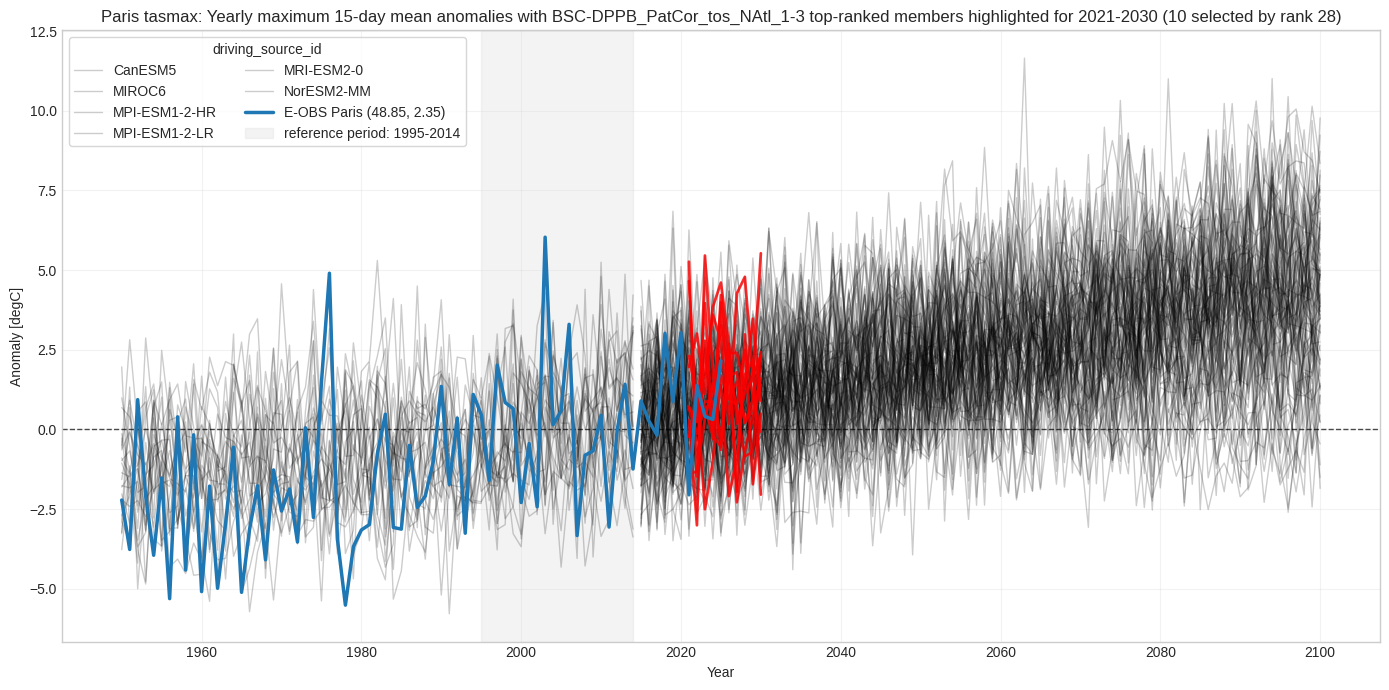

,rank,source_id,experiment_id,variant_label,correlation,member,selected
0,1,MRI-ESM2-0,ssp585,r5i1p1f1,0.588181,MRI-ESM2-0_ssp585_r5i1p1f1,
1,2,MIROC6,ssp585,r2i1p1f1,0.531176,MIROC6_ssp585_r2i1p1f1,
2,3,MIROC6,ssp585,r3i1p1f1,0.517919,MIROC6_ssp585_r3i1p1f1,
3,4,MRI-ESM2-0,ssp245,r3i1p1f1,0.503375,MRI-ESM2-0_ssp245_r3i1p1f1,
4,5,CNRM-CM6-1,ssp126,r1i1p1f2,0.497839,CNRM-CM6-1_ssp126_r1i1p1f2,
5,6,MIROC6,ssp126,r3i1p1f1,0.485030,MIROC6_ssp126_r3i1p1f1,yes
6,7,MIROC6,ssp245,r3i1p1f1,0.478012,MIROC6_ssp245_r3i1p1f1,
7,8,NorESM2-MM,ssp585,r1i1p1f1,0.474519,NorESM2-MM_ssp585_r1i1p1f1,
8,9,NorESM2-MM,ssp126,r1i1p1f1,0.472919,NorESM2-MM_ssp126_r1i1p1f1,
9,10,MIROC6,ssp370,r2i1p1f1,0.471337,MIROC6_ssp370_r2i1p1f1,yes


In [3]:
RANKING_REPOSITORY = "T52-Blending-information"
RANKING_METHOD_SPECS = {
    "NAO-Teleconnect": {
        "file_template": "{start_year}_pyrs20DJF_NAO_ObsTHoldPnt3_ERA5pslERA5tas_PatCor_NM250.csv",
        "layout": "long",
    },
    "BSC-DPPB_PatCor_tos_NAtl_1-3": {
        "file_template": "BSC-DPPB_PatCor_tos_s{start_year}_NAtl_cFYrs1-3_centered.csv",
        "layout": "long",
    },
    "Blend2C": {
        "file_template": "Blend2C_ranked_members_SubsetOBS_TAS_MED_JJA.csv",
        "layout": "wide",
    },
}

RANKING_HIGHLIGHT_START_YEAR = RANKING_START_YEAR + 1
RANKING_HIGHLIGHT_YEARS = 10
RANKING_HIGHLIGHT_COUNT = 10

ranking, ranking_members = load_ranking_members(
    RANKING_METHOD,
    RANKING_METHOD_SPECS,
    RANKING_REPOSITORY,
    RANKING_START_YEAR,
)

available_members = {str(member) for member in anomaly_metric.member.values}
ranked_members, selected_rows = select_ranked_members(
    ranking_members,
    available_members,
    RANKING_HIGHLIGHT_COUNT,
)

highlight_window_end = RANKING_HIGHLIGHT_START_YEAR + RANKING_HIGHLIGHT_YEARS - 1
rank_cutoff = len(selected_rows)
selection_summary = f"({len(ranked_members)} selected by rank {rank_cutoff})"

fig, ax = plt.subplots(figsize=(14, 7))
plot_member_ensemble(ax, anomaly_metric, alpha=0.2, linewidth=1.0, line_color="black")

for member in ranked_members:
    member_series = anomaly_metric.sel(member=member)
    segment = member_series.sel(year=slice(RANKING_HIGHLIGHT_START_YEAR, highlight_window_end))
    ax.plot(
        segment.year.values,
        segment.values,
        color="red",
        alpha=0.8,
        linewidth=2.0,
        zorder=4,
    )

ax.plot(
    eobs_anomaly.year.values,
    eobs_anomaly.values,
    color="#1f77b4",
    linewidth=2.5,
    label=f"E-OBS {eobs_metric.attrs['location_name']} ({eobs_metric.attrs['selected_lat']:.2f}, {eobs_metric.attrs['selected_lon']:.2f})",
    zorder=5,
)

format_time_series_axes(
    ax,
    f"{CITY} {VARIABLE}: {metric.title} anomalies with {RANKING_METHOD} top-ranked members highlighted for {RANKING_HIGHLIGHT_START_YEAR}-{highlight_window_end} {selection_summary}",
    f"Anomaly [{metric.attrs.get('units', '')}]",
    reference_period=REFERENCE_PERIOD,
    show_zero_line=True,
)
save_figure(fig, f"201_{CITY}_{VARIABLE}_{DIAGNOSTIC_ID}_{RANKING_METHOD}_{RANKING_START_YEAR}_ranked_members", config)
plt.show()

ranking_preview = ranking.iloc[: len(selected_rows)].copy()
ranking_preview.insert(0, "rank", range(1, len(ranking_preview) + 1))
ranking_preview["selected"] = ["yes" if value else "" for value in selected_rows]
ranking_preview

## Compare Full-Ensemble And Ranked-Subset Spread Across Start Years

This comparison tracks how ensemble spread changes when using the full ensemble versus the top-ranked subset for each available start year. The summary is computed over the highlight window and serves as a precursor to later skill diagnostics against observed evolution.

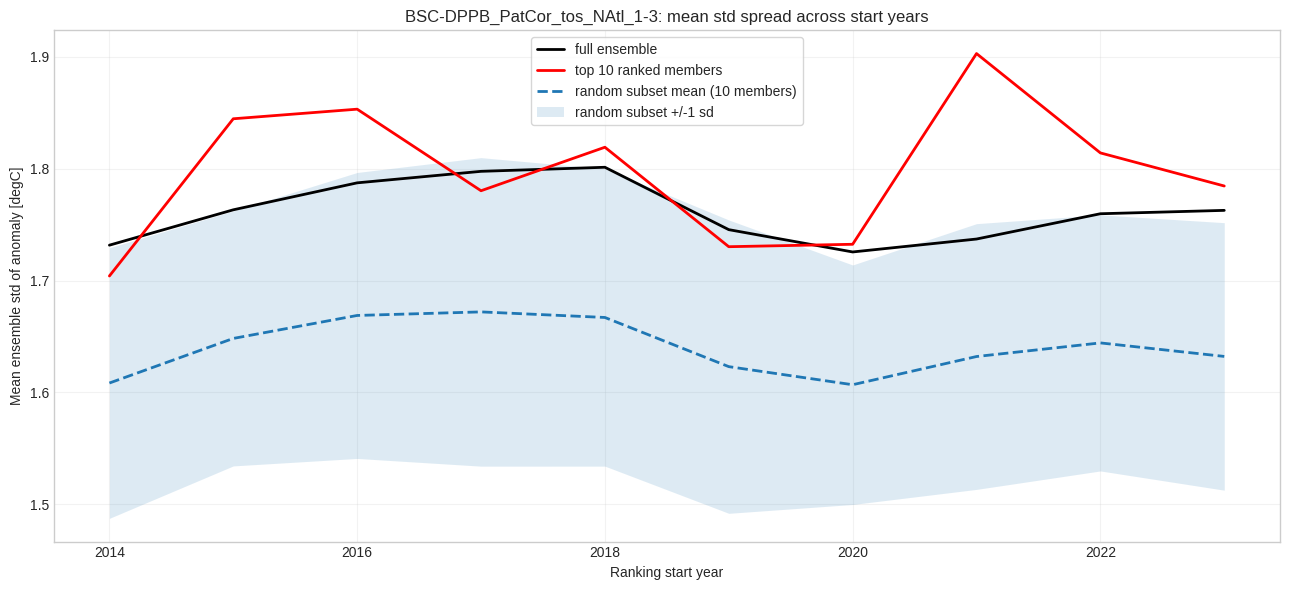

,method,start_year,window_start,window_end,n_ranked_members,rank_cutoff,full_spread,ranked_spread,random_spread,random_spread_std,ranked_minus_random_spread,ranked_to_random_spread_ratio,full_envelope_coverage,ranked_envelope_coverage,random_envelope_coverage,random_coverage_std,ranked_minus_random_coverage
0,BSC-DPPB_PatCor_tos_NAtl_1-3,2014,2015,2024,10,33,1.731661,1.704119,1.608438,0.120954,0.095681,1.059487,1.0,0.800000,0.833500,0.089823,-0.033500
1,BSC-DPPB_PatCor_tos_NAtl_1-3,2015,2016,2025,10,28,1.763269,1.844649,1.648301,0.113953,0.196348,1.119121,1.0,0.800000,0.827500,0.096125,-0.027500
2,BSC-DPPB_PatCor_tos_NAtl_1-3,2016,2017,2026,10,23,1.787378,1.853233,1.668836,0.127810,0.184397,1.110494,1.0,0.777778,0.815000,0.105249,-0.037222
3,BSC-DPPB_PatCor_tos_NAtl_1-3,2017,2018,2027,10,30,1.797664,1.780320,1.672024,0.137894,0.108296,1.064769,1.0,0.750000,0.790625,0.117513,-0.040625
4,BSC-DPPB_PatCor_tos_NAtl_1-3,2018,2019,2028,10,25,1.801302,1.819216,1.667042,0.132888,0.152174,1.091284,1.0,0.857143,0.840000,0.107707,0.017143
5,BSC-DPPB_PatCor_tos_NAtl_1-3,2019,2020,2029,10,30,1.745542,1.730298,1.623094,0.131123,0.107204,1.066049,1.0,0.833333,0.801667,0.128764,0.031667
6,BSC-DPPB_PatCor_tos_NAtl_1-3,2020,2021,2030,10,28,1.725600,1.732466,1.606921,0.107043,0.125545,1.078128,1.0,0.800000,0.821000,0.140919,-0.021000
7,BSC-DPPB_PatCor_tos_NAtl_1-3,2021,2022,2031,10,30,1.737152,1.902933,1.632131,0.118772,0.270802,1.165919,1.0,1.000000,0.960000,0.107624,0.040000
8,BSC-DPPB_PatCor_tos_NAtl_1-3,2022,2023,2032,10,30,1.759758,1.814137,1.644302,0.114450,0.169835,1.103287,1.0,1.000000,0.973333,0.090658,0.026667
9,BSC-DPPB_PatCor_tos_NAtl_1-3,2023,2024,2033,10,30,1.762776,1.784558,1.632220,0.119564,0.152338,1.093332,1.0,0.500000,0.975000,0.109246,-0.475000


In [4]:
SPREAD_METHOD = RANKING_METHOD
SPREAD_SUMMARY_STAT = "std"
SPREAD_HIGHLIGHT_COUNT = RANKING_HIGHLIGHT_COUNT
SPREAD_WINDOW_YEARS = RANKING_HIGHLIGHT_YEARS
SPREAD_RANDOM_SEED = 42
SPREAD_RANDOM_DRAWS = 200
AVAILABLE_START_YEARS = {
    "Blend2C": slice(1966, 2000),
    "NAO-Teleconnect": slice(1971, 2004),
    "BSC-DPPB_PatCor_tos_NAtl_1-3": slice(2014, 2024),
}

def resolve_start_years(method, start_years):
    method_years = start_years[method] if isinstance(start_years, dict) else start_years
    if isinstance(method_years, slice):
        if method_years.start is None or method_years.stop is None:
            raise ValueError(f"Slice start and stop must be defined for {method}")
        step = 1 if method_years.step is None else method_years.step
        return list(range(method_years.start, method_years.stop, step))
    return [int(start_year) for start_year in method_years]


def summarize_member_spread(metric_slice, statistic="std"):
    if metric_slice.sizes.get("member", 0) < 2:
        return float("nan")

    valid_members = metric_slice.notnull().any(dim="year")
    metric_slice = metric_slice.sel(member=metric_slice.member[valid_members])
    if metric_slice.sizes.get("member", 0) < 2:
        return float("nan")

    if statistic == "std":
        yearly_spread = metric_slice.std(dim="member", skipna=True)
    elif statistic == "range":
        yearly_spread = metric_slice.max(dim="member", skipna=True) - metric_slice.min(dim="member", skipna=True)
    elif statistic == "iqr":
        yearly_spread = metric_slice.quantile(0.75, dim="member") - metric_slice.quantile(0.25, dim="member")
    else:
        raise ValueError(f"Unsupported spread statistic: {statistic}")

    return float(yearly_spread.mean(dim="year", skipna=True).item())


def compute_envelope_coverage(metric_slice, observed_slice):
    overlap_years = observed_slice.year.to_index().intersection(metric_slice.year.to_index())
    if len(overlap_years) == 0 or metric_slice.sizes.get("member", 0) == 0:
        return float("nan")

    observed_window = observed_slice.sel(year=overlap_years)
    metric_window = metric_slice.sel(year=overlap_years)
    valid_members = metric_window.notnull().any(dim="year")
    metric_window = metric_window.sel(member=metric_window.member[valid_members])
    if metric_window.sizes.get("member", 0) == 0:
        return float("nan")

    covered = (
        (observed_window >= metric_window.min(dim="member", skipna=True))
        & (observed_window <= metric_window.max(dim="member", skipna=True))
    )
    return float(covered.mean().item())


def summarize_random_subset_baseline(full_slice, observed_slice, subset_size, rng, draws=200, statistic="std"):
    valid_mask = full_slice.notnull().any(dim="year")
    eligible_members = [str(member) for member in full_slice.member.values[valid_mask.values]]
    if len(eligible_members) < subset_size or subset_size < 2:
        return {
            "random_spread": float("nan"),
            "random_spread_std": float("nan"),
            "random_envelope_coverage": float("nan"),
            "random_coverage_std": float("nan"),
        }

    spread_samples = []
    coverage_samples = []
    for _ in range(draws):
        sampled_members = rng.choice(eligible_members, size=subset_size, replace=False).tolist()
        sampled_slice = full_slice.sel(member=sampled_members)
        spread_samples.append(summarize_member_spread(sampled_slice, statistic=statistic))
        coverage_samples.append(compute_envelope_coverage(sampled_slice, observed_slice))

    spread_samples = pd.Series(spread_samples, dtype=float)
    coverage_samples = pd.Series(coverage_samples, dtype=float)
    return {
        "random_spread": float(spread_samples.mean(skipna=True)),
        "random_spread_std": float(spread_samples.std(skipna=True)),
        "random_envelope_coverage": float(coverage_samples.mean(skipna=True)),
        "random_coverage_std": float(coverage_samples.std(skipna=True)),
    }


def compute_ranked_subset_spread_table(method, anomaly_metric, eobs_anomaly, ranking_method_specs, ranking_repository, start_years, highlight_count, window_years, statistic, random_seed, random_draws):
    available_members = [str(member) for member in anomaly_metric.member.values]
    available_member_set = set(available_members)
    available_start_years = resolve_start_years(method, start_years)
    rng = np.random.default_rng(random_seed)

    records = []
    for start_year in available_start_years:
        ranking, ranking_members = load_ranking_members(
            method, ranking_method_specs, ranking_repository, start_year
        )
        ranked_members, selected_rows = select_ranked_members(
            ranking_members, available_member_set, highlight_count
        )
        if not ranked_members:
            continue

        window_start = start_year + 1
        window_end = start_year + window_years
        full_slice = anomaly_metric.sel(year=slice(window_start, window_end))
        ranked_slice = full_slice.sel(member=ranked_members)
        eobs_slice = eobs_anomaly.sel(year=slice(window_start, window_end))

        if full_slice.sizes.get("year", 0) == 0 or ranked_slice.sizes.get("year", 0) == 0:
            continue

        full_spread = summarize_member_spread(full_slice, statistic=statistic)
        ranked_spread = summarize_member_spread(ranked_slice, statistic=statistic)
        full_coverage = compute_envelope_coverage(full_slice, eobs_slice)
        ranked_coverage = compute_envelope_coverage(ranked_slice, eobs_slice)
        random_baseline = summarize_random_subset_baseline(
            full_slice,
            eobs_slice,
            subset_size=len(ranked_members),
            rng=rng,
            draws=random_draws,
            statistic=statistic,
        )

        records.append({
            "method": method,
            "start_year": start_year,
            "window_start": window_start,
            "window_end": window_end,
            "n_ranked_members": len(ranked_members),
            "rank_cutoff": len(selected_rows),
            "full_spread": full_spread,
            "ranked_spread": ranked_spread,
            "random_spread": random_baseline["random_spread"],
            "random_spread_std": random_baseline["random_spread_std"],
            "ranked_minus_random_spread": ranked_spread - random_baseline["random_spread"],
            "ranked_to_random_spread_ratio": ranked_spread / random_baseline["random_spread"] if pd.notna(random_baseline["random_spread"]) and random_baseline["random_spread"] != 0 else float("nan"),
            "full_envelope_coverage": full_coverage,
            "ranked_envelope_coverage": ranked_coverage,
            "random_envelope_coverage": random_baseline["random_envelope_coverage"],
            "random_coverage_std": random_baseline["random_coverage_std"],
            "ranked_minus_random_coverage": ranked_coverage - random_baseline["random_envelope_coverage"],
        })

    if not records:
        raise ValueError(f"No valid spread comparisons were generated for {method}")

    return pd.DataFrame(records).sort_values("start_year").reset_index(drop=True)


spread_comparison = compute_ranked_subset_spread_table(
    SPREAD_METHOD,
    anomaly_metric,
    eobs_anomaly,
    RANKING_METHOD_SPECS,
    RANKING_REPOSITORY,
    start_years=AVAILABLE_START_YEARS,
    highlight_count=SPREAD_HIGHLIGHT_COUNT,
    window_years=SPREAD_WINDOW_YEARS,
    statistic=SPREAD_SUMMARY_STAT,
    random_seed=SPREAD_RANDOM_SEED,
    random_draws=SPREAD_RANDOM_DRAWS,
)
spread_comparison.to_csv(FIGURE_DIR / f"{CITY}_{VARIABLE}_{DIAGNOSTIC_ID}_{SPREAD_METHOD}_spread_comparison.csv", index=False)

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(spread_comparison["start_year"], spread_comparison["full_spread"], color="black", linewidth=2.0, label="full ensemble")
ax.plot(spread_comparison["start_year"], spread_comparison["ranked_spread"], color="red", linewidth=2.0, label=f"top {SPREAD_HIGHLIGHT_COUNT} ranked members")
ax.plot(spread_comparison["start_year"], spread_comparison["random_spread"], color="#1f77b4", linewidth=2.0, linestyle="--", label=f"random subset mean ({SPREAD_HIGHLIGHT_COUNT} members)")
ax.fill_between(
    spread_comparison["start_year"],
    spread_comparison["random_spread"] - spread_comparison["random_spread_std"],
    spread_comparison["random_spread"] + spread_comparison["random_spread_std"],
    color="#1f77b4",
    alpha=0.15,
    linewidth=0,
    label="random subset +/-1 sd",
)
ax.set_title(f"{SPREAD_METHOD}: mean {SPREAD_SUMMARY_STAT} spread across start years")
ax.set_xlabel("Ranking start year")
ax.set_ylabel(f"Mean ensemble {SPREAD_SUMMARY_STAT} of anomaly [{metric.attrs.get('units', '')}]")
ax.legend(frameon=True)
ax.grid(True, alpha=0.25)
plt.tight_layout()
save_figure(fig, f"202_{CITY}_{VARIABLE}_{DIAGNOSTIC_ID}_{SPREAD_METHOD}_spread_comparison", config)
plt.show()

spread_comparison

## Quantify Hindcast Skill By Forecast Horizon

This section considers whether the ranked subset gives more skillful decadal forecasts than random subsets of the same size. The verification unit is one forecast start date and one forecast horizon. For each start date, the forecast and the observation are averaged over the horizon first: year 1 is a one-year value, while years 2-5 and years 6-10 are multi-year means. This matches the decadal-prediction target: the score evaluates the predicted horizon mean, not year-to-year variability within the horizon.

For each start date $s$, horizon $h$, and member $m$, the code first computes a horizon-mean forecast anomaly

$$
f_{s,h,m} = \frac{1}{|h|}\sum_{y \in h} x_{s,y,m}
$$

and a matching horizon-mean observed anomaly

$$
o_{s,h} = \frac{1}{|h|}\sum_{y \in h} \text{obs}_y.
$$

The ranked subset, full ensemble, and each random subset are then scored across all available start dates for the same horizon. CRPS is computed for each start-date ensemble distribution and then averaged across start dates:

$$
CRPS = \frac{1}{N_s}\sum_s \left[\frac{1}{M}\sum_m |f_{s,h,m} - o_{s,h}| - \frac{1}{2M^2}\sum_m\sum_n |f_{s,h,m} - f_{s,h,n}|\right].
$$

Lower CRPS is better. It rewards ensemble distributions that are close to the observation while still accounting for ensemble spread. A CRPS of zero would mean a perfect ensemble forecast for every verified start date.

RMSE is computed from the ensemble mean forecast for each start date:

$$
RMSE = \sqrt{\frac{1}{N_s}\sum_s \left(\frac{1}{M}\sum_m f_{s,h,m} - o_{s,h}\right)^2}.
$$

Lower RMSE is better. It only evaluates the deterministic ensemble mean, so it does not reward or penalize the width of the ensemble distribution except through its effect on the mean.

The skill columns compare the ranked subset with two references:

$$
CRPSS_{ranked-vs-full} = 1 - \frac{CRPS_{ranked}}{CRPS_{full}}
$$

and

$$
CRPSS_{ranked-vs-rand} = 1 - \frac{CRPS_{ranked}}{CRPS_{rand}}.
$$

Positive values mean the ranked subset has lower CRPS than the reference; zero means equal CRPS; negative values mean the ranked subset is worse. For example, $0.2$ means a 20% CRPS reduction, while $-0.2$ means a 20% CRPS increase relative to the reference.

For RMSE, the improvement columns are simple differences:

$$
RMSE_{improve} = RMSE_{ref} - RMSE_{ranked}.
$$

Positive values mean the ranked subset has lower RMSE than the reference; zero means equal RMSE; negative values mean worse RMSE. The units are the same as the metric anomaly units.

The random-subset benchmark is estimated by repeated draws. For each draw, the code samples random members for every start date, computes the pooled horizon score, and stores the resulting CRPS and RMSE. The `ranked_beats_random_*_fraction` columns show the fraction of random draws that were worse than the ranked subset. Values near 1 indicate that the ranked subset usually beats random member selection; values near 0.5 suggest little separation from random selection; values near 0 indicate that random subsets usually perform better.

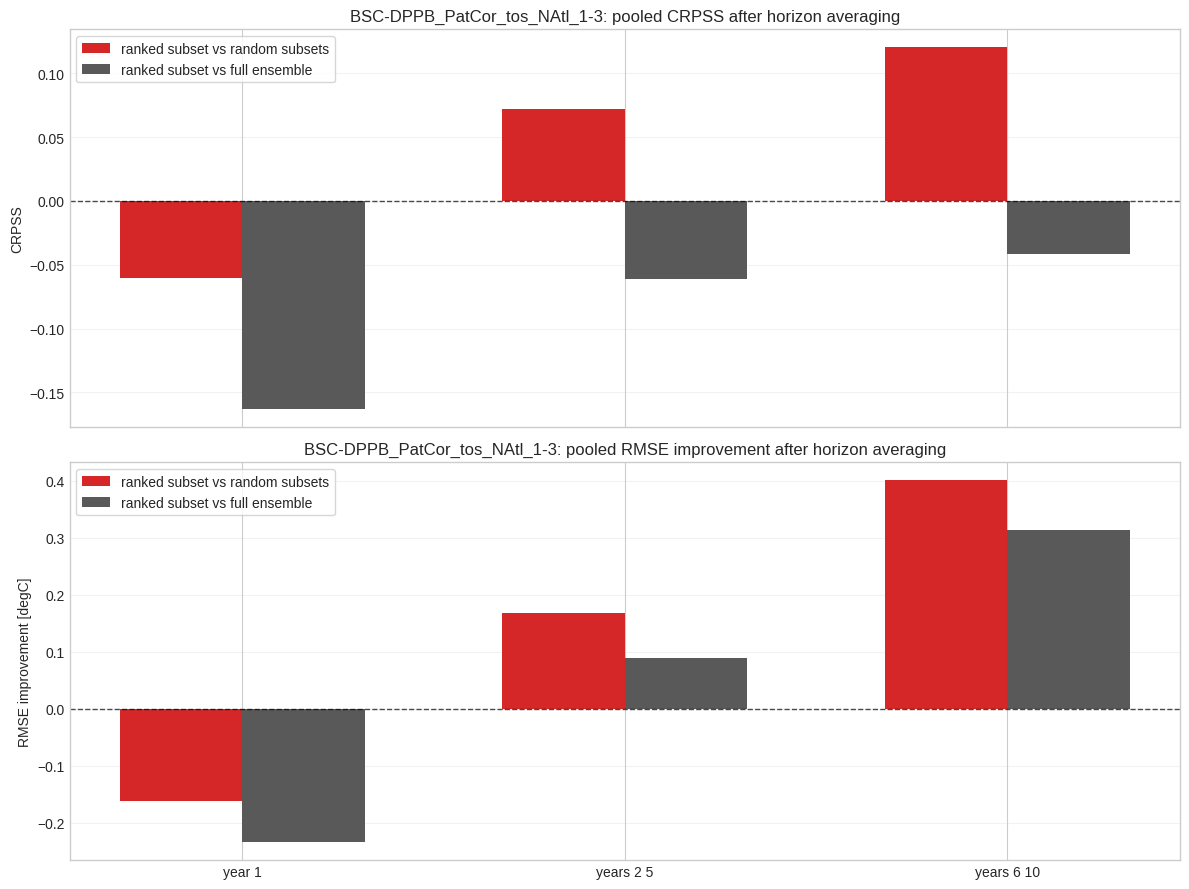

,horizon,method,lead_start,lead_end,n_start_dates,full_crps,ranked_crps,random_crps,random_crps_std,ranked_crpss_vs_full,random_crpss_vs_full,ranked_crpss_vs_random,ranked_beats_random_crps_fraction,full_rmse,ranked_rmse,random_rmse,random_rmse_std,ranked_rmse_improvement_vs_full,random_rmse_improvement_vs_full,ranked_rmse_improvement_vs_random,ranked_beats_random_rmse_fraction
0,year_1,BSC-DPPB_PatCor_tos_NAtl_1-3,1,1,10,0.900412,1.047220,0.987565,0.106695,-0.163046,-0.096793,-0.060406,0.28,1.533219,1.766652,1.604492,0.171367,-0.233433,-0.071273,-0.162160,0.195
1,years_2_5,BSC-DPPB_PatCor_tos_NAtl_1-3,2,5,10,0.425509,0.451518,0.486420,0.056638,-0.061126,-0.143151,0.071753,0.74,0.723298,0.633989,0.802514,0.128433,0.089310,-0.079215,0.168525,0.900
2,years_6_10,BSC-DPPB_PatCor_tos_NAtl_1-3,6,10,6,0.386116,0.402031,0.457036,0.081448,-0.041218,-0.183673,0.120350,0.74,0.684533,0.370440,0.770653,0.203731,0.314093,-0.086121,0.400214,0.985


In [5]:
HINDCAST_METHOD = SPREAD_METHOD
HINDCAST_HIGHLIGHT_COUNT = SPREAD_HIGHLIGHT_COUNT
HINDCAST_WINDOW_YEARS = SPREAD_WINDOW_YEARS
HINDCAST_START_YEARS = AVAILABLE_START_YEARS
HINDCAST_RANDOM_SEED = SPREAD_RANDOM_SEED
HINDCAST_RANDOM_DRAWS = SPREAD_RANDOM_DRAWS
HINDCAST_HORIZON_BINS = {
    "year_1": (1, 1),
    "years_2_5": (2, 5),
    "years_6_10": (6, 10),
}

def crps_ensemble(observation, ensemble_values):
    ensemble = np.asarray(ensemble_values, dtype=float)
    ensemble = ensemble[np.isfinite(ensemble)]
    if ensemble.size == 0 or not np.isfinite(observation):
        return float("nan")

    observation_term = np.mean(np.abs(ensemble - observation))
    pairwise_term = 0.5 * np.mean(np.abs(ensemble[:, None] - ensemble[None, :]))
    return float(observation_term - pairwise_term)


def rmse_ensemble_mean(observed_values, forecast_values):
    observed = np.asarray(observed_values, dtype=float)
    forecast = np.asarray(forecast_values, dtype=float)
    valid = np.isfinite(observed) & np.isfinite(forecast)
    if not np.any(valid):
        return float("nan")
    return float(np.sqrt(np.mean((forecast[valid] - observed[valid]) ** 2)))


def build_horizon_mean_case(metric_slice, observed_slice, years):
    if not years:
        return None

    metric_years = metric_slice.sel(year=years)
    observed_years = observed_slice.sel(year=years)
    if metric_years.sizes.get("year", 0) == 0 or observed_years.sizes.get("year", 0) == 0:
        return None

    member_means = metric_years.mean(dim="year", skipna=True)
    valid_members = member_means.notnull()
    ensemble_values = np.asarray(member_means.values[valid_members.values], dtype=float)
    observation = float(observed_years.mean(dim="year", skipna=True).item())
    if ensemble_values.size == 0 or not np.isfinite(observation):
        return None

    return {
        "observation": observation,
        "ensemble_values": ensemble_values,
        "ensemble_mean": float(np.mean(ensemble_values)),
        "n_members": int(ensemble_values.size),
        "n_years": len(years),
    }


def evaluate_horizon_mean_cases(cases):
    valid_cases = [case for case in cases if case is not None]
    if not valid_cases:
        return {"crps": float("nan"), "rmse": float("nan"), "n_cases": 0}

    crps_values = [crps_ensemble(case["observation"], case["ensemble_values"]) for case in valid_cases]
    observations = [case["observation"] for case in valid_cases]
    ensemble_means = [case["ensemble_mean"] for case in valid_cases]
    return {
        "crps": float(pd.Series(crps_values, dtype=float).mean(skipna=True)),
        "rmse": rmse_ensemble_mean(observations, ensemble_means),
        "n_cases": len(valid_cases),
    }


def sample_random_horizon_case(full_slice, observed_slice, years, subset_size, rng):
    full_case = build_horizon_mean_case(full_slice, observed_slice, years)
    if full_case is None or full_case["n_members"] < subset_size or subset_size < 2:
        return None

    metric_years = full_slice.sel(year=years)
    member_means = metric_years.mean(dim="year", skipna=True)
    valid_members = member_means.member.values[member_means.notnull().values]
    sampled_members = rng.choice(valid_members, size=subset_size, replace=False).tolist()
    sampled_slice = full_slice.sel(member=sampled_members)
    return build_horizon_mean_case(sampled_slice, observed_slice, years)


def summarize_random_strategy(case_specs, rng, draws=200):
    if not case_specs:
        return {
            "crps": float("nan"),
            "crps_std": float("nan"),
            "rmse": float("nan"),
            "rmse_std": float("nan"),
            "crps_samples": pd.Series(dtype=float),
            "rmse_samples": pd.Series(dtype=float),
        }

    crps_samples = []
    rmse_samples = []
    for _ in range(draws):
        sampled_cases = [
            sample_random_horizon_case(spec["full_slice"], spec["observed_slice"], spec["years"], spec["subset_size"], rng)
            for spec in case_specs
        ]
        sampled_skill = evaluate_horizon_mean_cases(sampled_cases)
        crps_samples.append(sampled_skill["crps"])
        rmse_samples.append(sampled_skill["rmse"])

    crps_samples = pd.Series(crps_samples, dtype=float)
    rmse_samples = pd.Series(rmse_samples, dtype=float)
    return {
        "crps": float(crps_samples.mean(skipna=True)),
        "crps_std": float(crps_samples.std(skipna=True)),
        "rmse": float(rmse_samples.mean(skipna=True)),
        "rmse_std": float(rmse_samples.std(skipna=True)),
        "crps_samples": crps_samples,
        "rmse_samples": rmse_samples,
    }


def compute_hindcast_skill_table(method, anomaly_metric, eobs_anomaly, ranking_method_specs, ranking_repository, start_years, highlight_count, window_years, horizon_bins, random_seed, random_draws):
    available_members = [str(member) for member in anomaly_metric.member.values]
    available_member_set = set(available_members)
    available_start_years = resolve_start_years(method, start_years)
    rng = np.random.default_rng(random_seed)

    horizon_cases = {horizon_name: {"full": [], "ranked": [], "random_specs": []} for horizon_name in horizon_bins}

    for start_year in available_start_years:
        ranking, ranking_members = load_ranking_members(method, ranking_method_specs, ranking_repository, start_year)
        ranked_members, selected_rows = select_ranked_members(ranking_members, available_member_set, highlight_count)
        if not ranked_members:
            continue

        window_start = start_year + 1
        window_end = start_year + window_years
        full_slice = anomaly_metric.sel(year=slice(window_start, window_end))
        ranked_slice = full_slice.sel(member=ranked_members)
        observed_slice = eobs_anomaly.sel(year=slice(window_start, window_end))

        if full_slice.sizes.get("year", 0) == 0 or ranked_slice.sizes.get("year", 0) == 0:
            continue

        overlap_years = sorted(set(int(year) for year in full_slice.year.values).intersection(int(year) for year in observed_slice.year.values))
        if not overlap_years:
            continue

        for horizon_name, lead_bounds in horizon_bins.items():
            lead_start, lead_end = lead_bounds
            horizon_years = [year for year in range(start_year + lead_start, start_year + lead_end + 1) if year in overlap_years]
            if not horizon_years:
                continue

            full_case = build_horizon_mean_case(full_slice, observed_slice, horizon_years)
            ranked_case = build_horizon_mean_case(ranked_slice, observed_slice, horizon_years)
            if full_case is None or ranked_case is None:
                continue

            full_case.update({"start_year": start_year, "years": horizon_years})
            ranked_case.update({"start_year": start_year, "years": horizon_years})
            horizon_cases[horizon_name]["full"].append(full_case)
            horizon_cases[horizon_name]["ranked"].append(ranked_case)
            horizon_cases[horizon_name]["random_specs"].append({
                "full_slice": full_slice,
                "observed_slice": observed_slice,
                "years": horizon_years,
                "subset_size": len(ranked_members),
                "start_year": start_year,
                "rank_cutoff": len(selected_rows),
            })

    records = []
    series_records = []
    for horizon_name, lead_bounds in horizon_bins.items():
        full_skill = evaluate_horizon_mean_cases(horizon_cases[horizon_name]["full"])
        ranked_skill = evaluate_horizon_mean_cases(horizon_cases[horizon_name]["ranked"])
        random_skill = summarize_random_strategy(horizon_cases[horizon_name]["random_specs"], rng, draws=random_draws)

        if full_skill["n_cases"] == 0 or ranked_skill["n_cases"] == 0:
            continue

        for full_case, ranked_case in zip(horizon_cases[horizon_name]["full"], horizon_cases[horizon_name]["ranked"]):
            series_records.append({
                "method": method,
                "horizon": horizon_name,
                "start_year": ranked_case["start_year"],
                "valid_years": ", ".join(str(year) for year in ranked_case["years"]),
                "observed": ranked_case["observation"],
                "ranked_ensemble_mean": ranked_case["ensemble_mean"],
                "full_ensemble_mean": full_case["ensemble_mean"],
            })

        records.append({
            "method": method,
            "horizon": horizon_name,
            "lead_start": lead_bounds[0],
            "lead_end": lead_bounds[1],
            "n_start_dates": ranked_skill["n_cases"],
            "full_crps": full_skill["crps"],
            "ranked_crps": ranked_skill["crps"],
            "random_crps": random_skill["crps"],
            "random_crps_std": random_skill["crps_std"],
            "ranked_crpss_vs_full": 1 - ranked_skill["crps"] / full_skill["crps"] if pd.notna(full_skill["crps"]) and full_skill["crps"] != 0 else float("nan"),
            "random_crpss_vs_full": 1 - random_skill["crps"] / full_skill["crps"] if pd.notna(full_skill["crps"]) and full_skill["crps"] != 0 else float("nan"),
            "ranked_crpss_vs_random": 1 - ranked_skill["crps"] / random_skill["crps"] if pd.notna(random_skill["crps"]) and random_skill["crps"] != 0 else float("nan"),
            "ranked_beats_random_crps_fraction": float((random_skill["crps_samples"] > ranked_skill["crps"]).mean()) if not random_skill["crps_samples"].empty else float("nan"),
            "full_rmse": full_skill["rmse"],
            "ranked_rmse": ranked_skill["rmse"],
            "random_rmse": random_skill["rmse"],
            "random_rmse_std": random_skill["rmse_std"],
            "ranked_rmse_improvement_vs_full": full_skill["rmse"] - ranked_skill["rmse"] if pd.notna(full_skill["rmse"]) and pd.notna(ranked_skill["rmse"]) else float("nan"),
            "random_rmse_improvement_vs_full": full_skill["rmse"] - random_skill["rmse"] if pd.notna(full_skill["rmse"]) and pd.notna(random_skill["rmse"]) else float("nan"),
            "ranked_rmse_improvement_vs_random": random_skill["rmse"] - ranked_skill["rmse"] if pd.notna(random_skill["rmse"]) and pd.notna(ranked_skill["rmse"]) else float("nan"),
            "ranked_beats_random_rmse_fraction": float((random_skill["rmse_samples"] > ranked_skill["rmse"]).mean()) if not random_skill["rmse_samples"].empty else float("nan"),
        })

    if not records:
        raise ValueError(f"No valid hindcast skill comparisons were generated for {method}")

    summary = pd.DataFrame(records).set_index("horizon").reindex(horizon_bins).reset_index()
    series = pd.DataFrame(series_records).sort_values(["horizon", "start_year"]).reset_index(drop=True)
    return summary, series


hindcast_skill_summary, hindcast_skill_series = compute_hindcast_skill_table(
    HINDCAST_METHOD,
    anomaly_metric,
    eobs_anomaly,
    RANKING_METHOD_SPECS,
    RANKING_REPOSITORY,
    HINDCAST_START_YEARS,
    HINDCAST_HIGHLIGHT_COUNT,
    HINDCAST_WINDOW_YEARS,
    HINDCAST_HORIZON_BINS,
    HINDCAST_RANDOM_SEED,
    HINDCAST_RANDOM_DRAWS,
)
hindcast_skill_summary.to_csv(FIGURE_DIR / f"{CITY}_{VARIABLE}_{DIAGNOSTIC_ID}_{HINDCAST_METHOD}_hindcast_skill_summary.csv", index=False)
hindcast_skill_series.to_csv(FIGURE_DIR / f"{CITY}_{VARIABLE}_{DIAGNOSTIC_ID}_{HINDCAST_METHOD}_hindcast_skill_series.csv", index=False)

horizon_labels = hindcast_skill_summary["horizon"].str.replace("_", " ")
x = np.arange(len(hindcast_skill_summary))
bar_width = 0.32

fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

axes[0].bar(x - bar_width / 2, hindcast_skill_summary["ranked_crpss_vs_random"], width=bar_width, color="tab:red", label="ranked subset vs random subsets")
axes[0].bar(x + bar_width / 2, hindcast_skill_summary["ranked_crpss_vs_full"], width=bar_width, color="0.35", label="ranked subset vs full ensemble")
axes[0].axhline(0, color="black", linewidth=1.0, linestyle="--", alpha=0.7)
axes[0].set_title(f"{HINDCAST_METHOD}: pooled CRPSS after horizon averaging")
axes[0].set_ylabel("CRPSS")
axes[0].legend(frameon=True)
axes[0].grid(True, axis="y", alpha=0.25)

axes[1].bar(x - bar_width / 2, hindcast_skill_summary["ranked_rmse_improvement_vs_random"], width=bar_width, color="tab:red", label="ranked subset vs random subsets")
axes[1].bar(x + bar_width / 2, hindcast_skill_summary["ranked_rmse_improvement_vs_full"], width=bar_width, color="0.35", label="ranked subset vs full ensemble")
axes[1].axhline(0, color="black", linewidth=1.0, linestyle="--", alpha=0.7)
axes[1].set_title(f"{HINDCAST_METHOD}: pooled RMSE improvement after horizon averaging")
axes[1].set_ylabel(f"RMSE improvement [{metric.attrs.get('units', '')}]")
axes[1].set_xticks(x)
axes[1].set_xticklabels(horizon_labels)
axes[1].legend(frameon=True)
axes[1].grid(True, axis="y", alpha=0.25)

plt.tight_layout()
save_figure(fig, f"203_{CITY}_{VARIABLE}_{DIAGNOSTIC_ID}_{HINDCAST_METHOD}_hindcast_skill", config)
plt.show()

hindcast_skill_summary